In [ ]:
import math
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml
from PyLTSpice import RawRead

%config InlineBackend.figure_format = 'svg'

In [ ]:
"""
Gamma Spectrometer Noise Analysis

This module analyzes the output noise characteristics of the analog front-end
and compares against system requirements.
"""

# ============================================
# Load Configuration
# ============================================
with open("config.yaml", "r", encoding="utf-8") as config_file:
    config = yaml.safe_load(config_file)

# ============================================
# Output Directory Setup
# ============================================

REPORT_DIR = Path(config["paths"]["report_directory"])
REPORT_DIR.mkdir(exist_ok=True)

print(f"Reports directory ready at: {os.path.abspath(REPORT_DIR)}")

Reports directory ready at: /workspace/05_Verification/ElectronicHardware/Simulation/Analog/ANA-001_OutputNoise/04_Report


Theoretical CSA bandwidth: 0.0 kHz
AFE output noise (0-20MHz): 31.68 uV RMS
ADC noise contribution: 131.76 uV RMS
Reference noise: 50.00 uV RMS
Total system noise: 135.51 uV RMS
Input-referred RMS noise: 0.00 nA
Noise as percentage of FS: 0.0192%
System SNR: 74.35 dB
System ENOB: 12.06 bits

========== REQUIREMENTS COMPLIANCE ==========
Requirement (ANA-001): ≤ 1500.00 uV RMS
Measured: 135.51 uV RMS
Status: PASS

Requirement (Physics): ≤ 0.43% of FS
Measured: 0.0192% of FS
Status: PASS


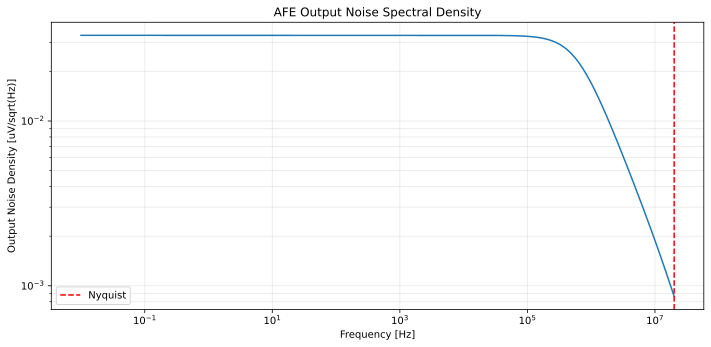

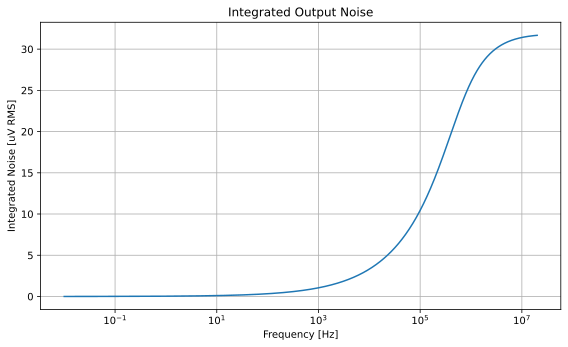

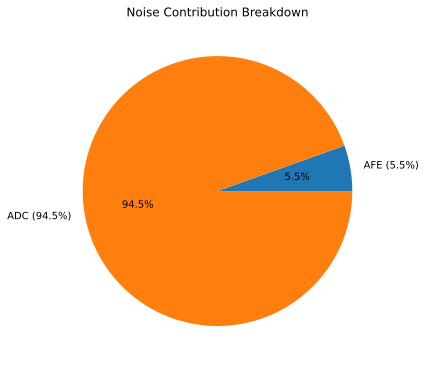

In [3]:
# ============================================
# Load Simulation Results
# ============================================
raw_path = config["paths"]["simulation_results"]
raw = RawRead(raw_path)

freq = raw.get_trace("frequency").get_wave(0)
onoise = np.abs(raw.get_trace("V(onoise)").get_wave(0))

# ============================================
# Load Parameters from Config
# ============================================

# ADC parameters - explicitly convert to numeric types
adc_input_span = float(config["adc"]["input_span"])
adc_bits = int(config["adc"]["bits"])
adc_lsb_size = float(config["adc"]["lsb_size"])
adc_input_noise_lsb = float(config["adc"]["input_noise_lsb"])
adc_noise_vrms = adc_input_noise_lsb * adc_lsb_size
adc_snr_db = float(config["adc"]["snr"]["low_freq"])

# CSA parameters
R_F = float(config["csa"]["rf"])
C_F = float(config["csa"]["cf"])

theoretical_bandwidth = 1 / (2 * math.pi * R_F * C_F)
print(f"Theoretical CSA bandwidth: {theoretical_bandwidth / 1e3:.1f} kHz")

# Analysis parameters
f_low = float(config["analysis"]["f_low"])
f_high = float(config["analysis"]["f_high"])
ref_noise_vrms = float(config["analysis"]["reference_noise"])

# Requirements
req_noise_max = float(config["requirements"]["noise_max"])
req_noise_percent = float(config["requirements"]["noise_percent"])

# ============================================
# Calculate AFE Noise
# ============================================
mask = (freq >= f_low) & (freq <= f_high)
freq_band = freq[mask]
onoise_band = onoise[mask]

# Integrate noise numerically across bandwidth
afe_noise_vrms = np.sqrt(np.trapezoid(onoise_band**2, freq_band))
print(f"AFE output noise (0-20MHz): {afe_noise_vrms * 1e6:.2f} uV RMS")


# ============================================
# Calculate System Noise
# ============================================

# Total system noise (RSS combination)
total_noise_vrms = np.sqrt(afe_noise_vrms**2 + adc_noise_vrms**2)
print(f"ADC noise contribution: {adc_noise_vrms * 1e6:.2f} uV RMS")
print(f"Reference noise: {ref_noise_vrms * 1e6:.2f} uV RMS")
print(f"Total system noise: {total_noise_vrms * 1e6:.2f} uV RMS")

# ============================================
# Calculate Input-Referred Noise
# ============================================
input_noise_rms = afe_noise_vrms / R_F
print(f"Input-referred RMS noise: {input_noise_rms * 1e9:.2f} nA")

# ============================================
# Calculate Performance Metrics
# ============================================
# Full-scale RMS value (for 2Vpp differential)
fs_rms = adc_input_span / (2 * np.sqrt(2))  # ~0.707 V RMS

# Noise as percentage of full scale
noise_percent = (total_noise_vrms / fs_rms) * 100
print(f"Noise as percentage of FS: {noise_percent:.4f}%")

# System SNR
system_snr = 20 * np.log10(fs_rms / total_noise_vrms)
print(f"System SNR: {system_snr:.2f} dB")

# System ENOB
system_enob = (system_snr - 1.76) / 6.02
print(f"System ENOB: {system_enob:.2f} bits")

# ============================================
# Compare Against Requirements
# ============================================
req_noise_max = 1.5e-3  # 1.5 mV RMS from ANA-001
req_noise_percent = 0.43  # 0.43% from detector physics analysis

print("\n========== REQUIREMENTS COMPLIANCE ==========")
print(f"Requirement (ANA-001): ≤ {req_noise_max * 1e6:.2f} uV RMS")
print(f"Measured: {total_noise_vrms * 1e6:.2f} uV RMS")
print(f"Status: {'PASS' if total_noise_vrms <= req_noise_max else 'FAIL'}")

print(f"\nRequirement (Physics): ≤ {req_noise_percent:.2f}% of FS")
print(f"Measured: {noise_percent:.4f}% of FS")
print(f"Status: {'PASS' if noise_percent <= req_noise_percent else 'FAIL'}")
print("============================================")

# ============================================
# PLOTS
# ============================================
# Noise Spectral Density
plt.figure(figsize=(10, 5))
plt.loglog(freq, onoise * 1e6)
plt.axvline(f_high, color="r", linestyle="--", label="Nyquist")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Output Noise Density [uV/sqrt(Hz)]")
plt.title("AFE Output Noise Spectral Density")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(REPORT_DIR / "AfeOutputNoiseSpectralDensity.svg", format="svg")

# Cumulative Integrated Noise
cumulative = np.sqrt(np.cumsum(onoise_band**2 * np.gradient(freq_band)))
plt.figure(figsize=(8, 5))
plt.semilogx(freq_band, cumulative * 1e6)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Integrated Noise [uV RMS]")
plt.title("Integrated Output Noise")
plt.grid(True, which="both")
plt.tight_layout()
plt.savefig(REPORT_DIR / "IntegratedOutputNoise.svg", format="svg")

# Noise Contribution Breakdown
var_afe = afe_noise_vrms**2
var_adc = adc_noise_vrms**2
var_total = var_afe + var_adc
percentages = [100 * var_afe / var_total, 100 * var_adc / var_total]
labels = [f"AFE ({percentages[0]:.1f}%)", f"ADC ({percentages[1]:.1f}%)"]

plt.figure(figsize=(6, 6))
plt.pie(percentages, labels=labels, autopct="%1.1f%%")
plt.title("Noise Contribution Breakdown")
plt.tight_layout()
plt.savefig(REPORT_DIR / "NoiseContributionBreakdown.svg", format="svg")

plt.show()